# Extreme-Value Theorem for Maxima

If properly normalized maxima converge, the limit belongs to the GEV family.
We illustrate convergence for the three signs of shape parameter $\xi$:
Fréchet ($\xi>0$), Gumbel ($\xi=0$), Weibull ($\xi<0$).


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

def max_samples(kind, n, m=22000):
    if kind == 'frechet':
        x = rng.pareto(2.2, size=(m, n)) + 1
        a = n**(1/2.2); b = 0.0
    elif kind == 'gumbel':
        x = rng.normal(size=(m, n))
        a = 1/np.sqrt(2*np.log(n)); b = np.sqrt(2*np.log(n))
    else:  # weibull via bounded uniforms
        x = rng.uniform(0, 1, size=(m, n))
        a = n; b = 1.0
    M = np.max(x, axis=1)
    return (M - b) * a


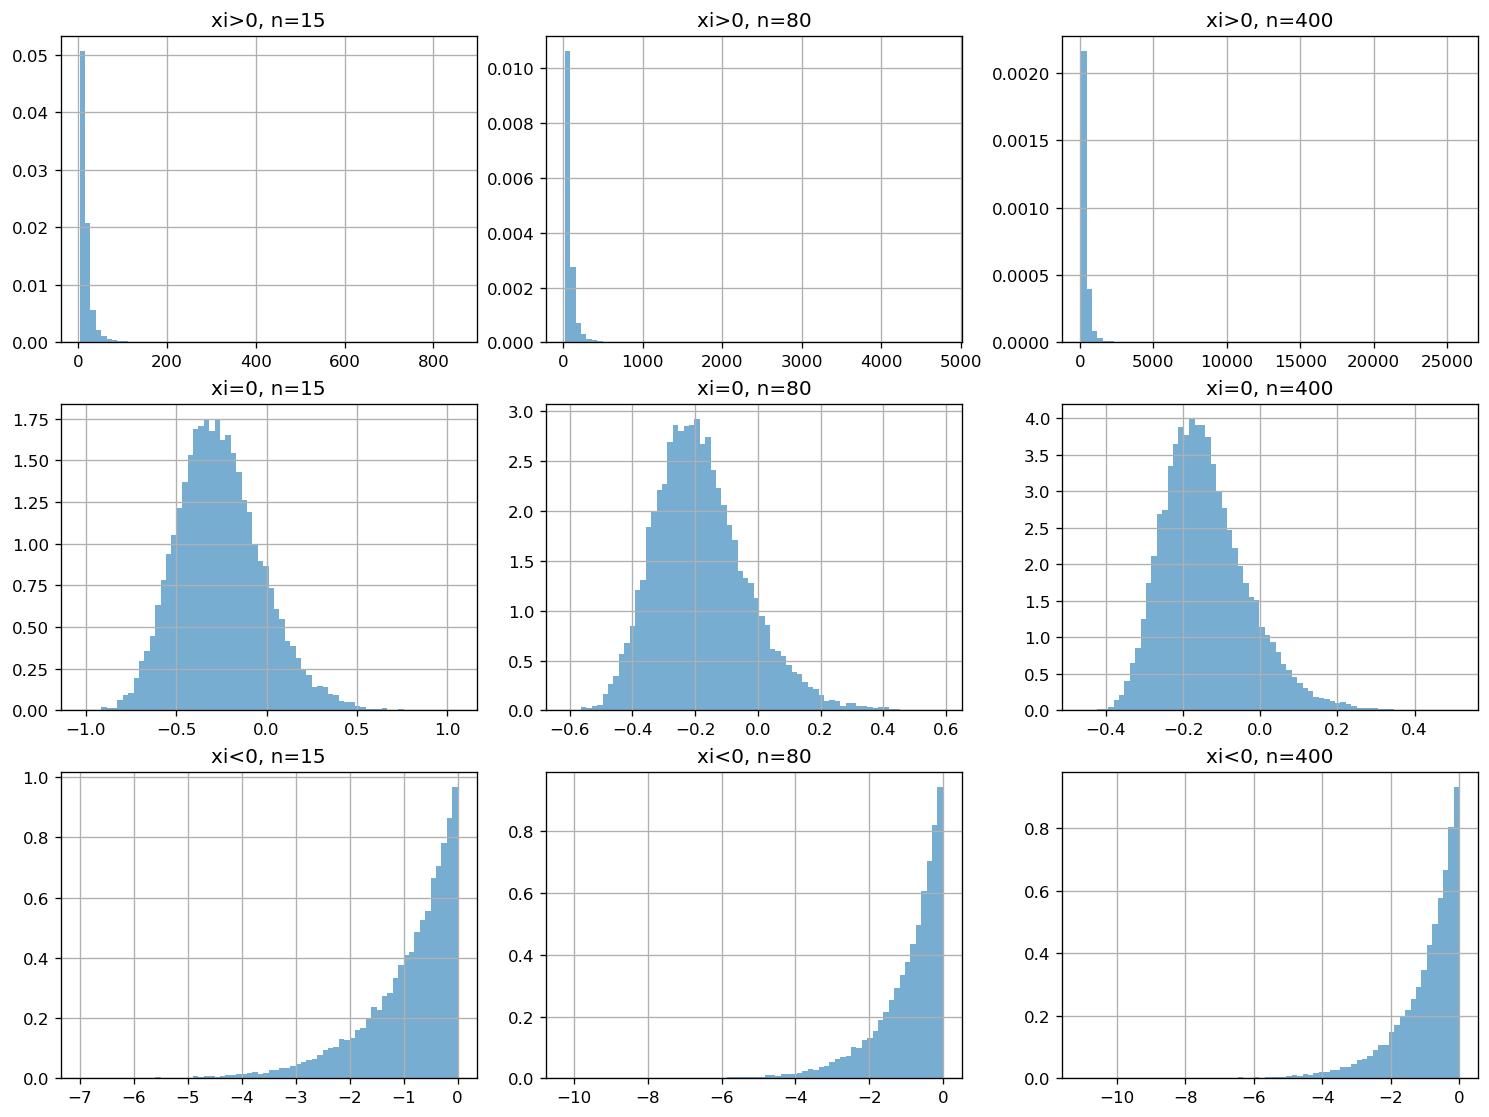

In [2]:
cases = [('frechet', 'xi>0'), ('gumbel', 'xi=0'), ('weibull', 'xi<0')]
ns = [15, 80, 400]
fig, axes = plt.subplots(3, 3, figsize=(12.3, 9.2), constrained_layout=True)
for r, (kind, lbl) in enumerate(cases):
    for c, n in enumerate(ns):
        z = max_samples(kind, n)
        axes[r,c].hist(z, bins=70, density=True, alpha=0.6, color='tab:blue')
        axes[r,c].set_title(f'{lbl}, n={n}')
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
